#### 一个物体从滑道往下滑，起点坐标（0米，1000米），终点坐标（800米，0米），
#### （1）无摩擦的情况

下滑到终点的时间为： 17.4548430595553 秒


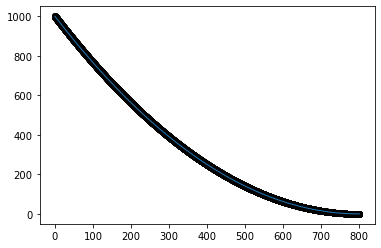

In [10]:
import random  # 随机函数包
import matplotlib.pyplot as plt  # 绘图模块调用
# from scipy.interpolate import spline
from scipy.interpolate import make_interp_spline


def CalLineTime(height,width,v0): #计算直线下坡的速度，v0为初始速度
    Linelen=(height**2+width**2)**0.5
    g=9.8   #重力加速度
    acc=g*height/Linelen  #a/g=h/l
    b24ac=4*v0**2+8*acc*Linelen
    if(b24ac<0):
        print("速度降为0，无法继续运动")
        return(-1,0)
    if(acc==0): t=Linelen/v0  #t=l/v if a=0
    else:
        t= (b24ac**0.5-2*v0)/(2*acc)  #t=(sqrt(4v*v+8al)-2v)/(2a)
        v0=v0+acc*t
    #print(Linelen,acc,t,v0)
    return(t,v0) #反馈计算获得的时长和最终速度

#以下产生曲线数据
b=width
a=height/width**2
wsize=10000
wgrid=width/wsize
x=[0]*(wsize+1)
y=[0]*(wsize+1)
for i in range(wsize+1):
    x[i]=i*wgrid
    y[i]=a*(x[i]-width)**2
#以下计算下降时间
t = 0
myv0 = 0
for i in range(wsize):
    mytime,myv0 = CalLineTime(y[i]-y[i+1],x[i+1]-x[i],myv0)
    t+= mytime
print("下滑到终点的时间为：",t,"秒") 
fig, ax = plt.subplots()  #启动画图
plt.scatter(x, y, c='black', alpha=0.5)  # 散点图： alpha:透明度) c:颜色
plt.plot(x, y, linewidth=1)  # 折线图：线宽linewidth=1


#### （2）有摩擦的情况，摩擦因子等于0.1

下滑到终点的时间为： 17.887681618981258 秒


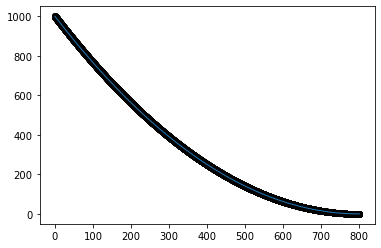

In [11]:
def CalLineTime(height, width, v0):
    # 计算直线长度
    Linelen = (height ** 2 + width ** 2) ** 0.5
    # 重力加速度
    g = 9.8
    # 摩擦因子
    mu = 0.1
    # 计算考虑摩擦力后的加速度
    acc = g * height / Linelen - mu * g * width / Linelen
    # 计算判别式
    b24ac = 4 * v0 ** 2 + 8 * acc * Linelen
    if b24ac < 0:
        print("速度降为0，无法继续运动")
        return -1, 0
    if acc == 0:
        # 如果加速度为0，做匀速运动
        t = Linelen / v0
    else:
        # 计算运动时间
        t = (b24ac ** 0.5 - 2 * v0) / (2 * acc)
        # 计算最终速度
        v0 = v0 + acc * t
    return t, v0

#以下产生曲线数据
b=width
a=height/width**2
wsize=10000
wgrid=width/wsize
x=[0]*(wsize+1)
y=[0]*(wsize+1)
for i in range(wsize+1):
    x[i]=i*wgrid
    y[i]=a*(x[i]-width)**2
#以下计算下降时间
t = 0
myv0 = 0
for i in range(wsize):
    mytime,myv0 = CalLineTime(y[i]-y[i+1],x[i+1]-x[i],myv0)
    t+= mytime
print("下滑到终点的时间为：",t,"秒") 
fig, ax = plt.subplots()  #启动画图
plt.scatter(x, y, c='black', alpha=0.5)  # 散点图： alpha:透明度) c:颜色
plt.plot(x, y, linewidth=1)  # 折线图：线宽linewidth=1
